# Model Performance Evaluation

Evaluate saved RSCD checkpoints in `models/checkpoints` on validation and test splits.


In [18]:
from __future__ import annotations

import json
from dataclasses import dataclass
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, models, transforms


In [19]:
# Paths and runtime config
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
if (ROOT / 'camera_model').exists():
    PROJECT_ROOT = ROOT
else:
    PROJECT_ROOT = ROOT.parent

CHECKPOINTS_DIR = PROJECT_ROOT / 'models' / 'checkpoints'
MODELS_DIR = CHECKPOINTS_DIR  # backward-compat variable used below
DATA_ROOT = PROJECT_ROOT / 'camera_model' / 'data' / 'RSCD dataset-1million'
VAL_DIR = DATA_ROOT / 'vali_20k'
TEST_DIR = DATA_ROOT / 'test_50k'
SUMMARY_PATH = PROJECT_ROOT / 'models' / 'eval' / 'eval_summary.json'

RUN_EVALUATION = False  # False = load cached summary and plot instantly
QUICK_MODE = True

BATCH_SIZE = 128
NUM_WORKERS = 0  # keep 0 in notebooks on macOS (spawn/pickle issue)
IMAGE_SIZE = 224
MAX_SAMPLES = 5000 if QUICK_MODE else None
SEED = 42

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'Run evaluation: {RUN_EVALUATION}')
print(f'Quick mode: {QUICK_MODE} | max_samples={MAX_SAMPLES}')
print(f'Checkpoints dir: {CHECKPOINTS_DIR}')
print(f'Summary path: {SUMMARY_PATH}')



Device: mps
Run evaluation: False
Quick mode: True | max_samples=5000
Checkpoints dir: /Users/williamsaether/Documents/GitHub/EiT-TDT4861-G6/models/checkpoints
Summary path: /Users/williamsaether/Documents/GitHub/EiT-TDT4861-G6/models/eval/eval_summary.json


In [20]:
def normalize_label(label: str) -> Optional[str]:
    if 'concrete' in label:
        return None
    return label.replace('_severe', '').replace('_slight', '').replace('_smooth', '')


def parse_label_from_filename(path: Path) -> str:
    stem = path.stem
    if '-' not in stem:
        return stem
    _, label = stem.split('-', 1)
    return label.replace('-', '_')


class RSCDFlatDataset(Dataset):
    def __init__(self, root_dir: Path, transform=None, class_to_idx: Optional[dict[str, int]] = None):
        self.root_dir = root_dir
        self.transform = transform
        self.class_to_idx = class_to_idx or {}
        all_samples = sorted([p for p in root_dir.iterdir() if p.is_file()])
        self.samples = [
            p for p in all_samples if normalize_label(parse_label_from_filename(p)) in self.class_to_idx
        ]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int):
        path = self.samples[idx]
        label_name = normalize_label(parse_label_from_filename(path))
        label = self.class_to_idx[label_name]
        img = datasets.folder.default_loader(path)
        if self.transform:
            img = self.transform(img)
        return img, label


def maybe_subset(ds: Dataset, max_samples: Optional[int], seed: int) -> Dataset:
    if max_samples is None or max_samples >= len(ds):
        return ds
    rng = np.random.default_rng(seed)
    indices = rng.permutation(len(ds))[:max_samples]
    return Subset(ds, indices)


def build_model(num_classes: int) -> nn.Module:
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


In [21]:
@dataclass
class EvalStats:
    loss: float
    accuracy: float
    macro_precision: float
    macro_recall: float
    macro_f1: float
    n_samples: int
    confusion: np.ndarray
def evaluate(model: nn.Module, loader: DataLoader, device: torch.device) -> EvalStats:
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total = 0
    loss_sum = 0.0
    all_preds = []
    all_labels = []
    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
            labels = labels.to(device, non_blocking=True)
            with torch.amp.autocast(device_type='cuda', enabled=(device.type == 'cuda')):
                logits = model(images)
                loss = criterion(logits, labels)
            preds = logits.argmax(dim=1)
            loss_sum += loss.item() * labels.size(0)
            total += labels.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
    preds = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    num_classes = int(max(labels.max(), preds.max()) + 1)
    confusion = np.zeros((num_classes, num_classes), dtype=np.int64)
    np.add.at(confusion, (labels, preds), 1)
    tp = np.diag(confusion).astype(np.float64)
    pred_pos = confusion.sum(axis=0).astype(np.float64)
    actual_pos = confusion.sum(axis=1).astype(np.float64)
    precision = np.divide(tp, pred_pos, out=np.zeros_like(tp), where=pred_pos > 0)
    recall = np.divide(tp, actual_pos, out=np.zeros_like(tp), where=actual_pos > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)
    return EvalStats(
        loss=loss_sum / total,
        accuracy=float((preds == labels).mean()),
        macro_precision=float(precision.mean()),
        macro_recall=float(recall.mean()),
        macro_f1=float(f1.mean()),
        n_samples=total,
        confusion=confusion,
    )
def top_confusions(confusion: np.ndarray, idx_to_class: dict[int, str], top_k: int = 8):
    c = confusion.copy()
    np.fill_diagonal(c, 0)
    entries = []
    flat_idx = np.argsort(c, axis=None)[::-1]
    for idx in flat_idx:
        count = int(c.flat[idx])
        if count <= 0:
            break
        true_idx, pred_idx = np.unravel_index(idx, c.shape)
        entries.append((idx_to_class[true_idx], idx_to_class[pred_idx], count))
        if len(entries) >= top_k:
            break
    return entries


In [22]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
eval_tfms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

checkpoints = sorted(CHECKPOINTS_DIR.glob('*.pt'))
assert checkpoints, f'No checkpoints found in {CHECKPOINTS_DIR}'
print('Found checkpoints:')
for ckpt in checkpoints:
    print('-', ckpt.name)


Found checkpoints:
- rscd_resnet18.pt
- rscd_resnet18_v2.pt


In [23]:
results = []

if RUN_EVALUATION:
    # Optional: evaluate only one checkpoint
    # checkpoints = [CHECKPOINTS_DIR / 'rscd_resnet18_v2.pt']
    for checkpoint_path in checkpoints:
        ckpt = torch.load(checkpoint_path, map_location='cpu')
        if 'model_state' not in ckpt or 'class_to_idx' not in ckpt:
            print(f'Skipping {checkpoint_path.name}: missing model_state/class_to_idx')
            continue

        class_to_idx = ckpt['class_to_idx']
        idx_to_class = {v: k for k, v in class_to_idx.items()}

        model = build_model(num_classes=len(class_to_idx)).to(DEVICE, memory_format=torch.channels_last)
        model.load_state_dict(ckpt['model_state'], strict=True)

        val_ds = maybe_subset(RSCDFlatDataset(VAL_DIR, transform=eval_tfms, class_to_idx=class_to_idx), MAX_SAMPLES, SEED)
        test_ds = maybe_subset(RSCDFlatDataset(TEST_DIR, transform=eval_tfms, class_to_idx=class_to_idx), MAX_SAMPLES, SEED)

        loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == 'cuda'), shuffle=False)
        val_loader = DataLoader(val_ds, **loader_kwargs)
        test_loader = DataLoader(test_ds, **loader_kwargs)

        print(f'\n=== {checkpoint_path.name} ({len(class_to_idx)} classes) ===')
        val_stats = evaluate(model, val_loader, DEVICE)
        test_stats = evaluate(model, test_loader, DEVICE)

        print(f'Val:  acc={val_stats.accuracy:.4f} macro_f1={val_stats.macro_f1:.4f}')
        print(f'Test: acc={test_stats.accuracy:.4f} macro_f1={test_stats.macro_f1:.4f}')

        results.append({
            'checkpoint': checkpoint_path.name,
            'n_classes': len(class_to_idx),
            'class_names': [idx_to_class[i] for i in range(len(idx_to_class))],
            'val': {
                'loss': val_stats.loss,
                'accuracy': val_stats.accuracy,
                'macro_precision': val_stats.macro_precision,
                'macro_recall': val_stats.macro_recall,
                'macro_f1': val_stats.macro_f1,
                'n_samples': val_stats.n_samples,
                'confusion': val_stats.confusion.tolist(),
            },
            'test': {
                'loss': test_stats.loss,
                'accuracy': test_stats.accuracy,
                'macro_precision': test_stats.macro_precision,
                'macro_recall': test_stats.macro_recall,
                'macro_f1': test_stats.macro_f1,
                'n_samples': test_stats.n_samples,
                'confusion': test_stats.confusion.tolist(),
            },
        })

    SUMMARY_PATH.write_text(json.dumps(results, indent=2), encoding='utf-8')
    print(f'\nSaved summary to {SUMMARY_PATH}')
else:
    assert SUMMARY_PATH.exists(), f'Missing summary: {SUMMARY_PATH}'
    results = json.loads(SUMMARY_PATH.read_text(encoding='utf-8'))
    print(f'Loaded {len(results)} model results from {SUMMARY_PATH}')


Loaded 2 model results from /Users/williamsaether/Documents/GitHub/EiT-TDT4861-G6/models/eval/eval_summary.json


In [24]:
# Compact comparison table (fair unified-12 comparison)
if not results:
    print('No results collected.')
else:
    def getv(r, split, key):
        if split in r and isinstance(r[split], dict):
            return r[split].get(key)
        return r.get(f'{split}_{key}')

    def map_to_unified_12(label: str, allowed: set[str]) -> str | None:
        s = str(label)
        if 'concrete' in s:
            if s.startswith('dry_') or s.startswith('wet_') or s.startswith('water_'):
                s = s.replace('concrete', 'asphalt')
        for suf in ('_severe', '_slight', '_smooth'):
            if s.endswith(suf):
                s = s[: -len(suf)]
                break
        return s if s in allowed else None

    def confusion_to_macro_f1(cm: np.ndarray) -> float:
        tp = np.diag(cm).astype(float)
        pred_pos = cm.sum(axis=0).astype(float)
        actual_pos = cm.sum(axis=1).astype(float)
        precision = np.divide(tp, pred_pos, out=np.zeros_like(tp), where=pred_pos > 0)
        recall = np.divide(tp, actual_pos, out=np.zeros_like(tp), where=actual_pos > 0)
        f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)
        return float(f1.mean())

    row12 = next((r for r in results if int(r.get('n_classes', 0)) == 12), None)
    if row12 is not None and row12.get('class_names'):
        unified_classes = list(row12['class_names'])
    else:
        unified_classes = [
            'dry_asphalt', 'dry_gravel', 'dry_mud', 'fresh_snow', 'ice', 'melted_snow',
            'water_asphalt', 'water_gravel', 'water_mud', 'wet_asphalt', 'wet_gravel', 'wet_mud'
        ]

    allowed = set(unified_classes)
    idx = {c: i for i, c in enumerate(unified_classes)}

    fair_rows = []
    for r in results:
        cm = np.array(r['test']['confusion'], dtype=int)
        src_classes = list(r.get('class_names', [str(i) for i in range(cm.shape[0])]))
        ucm = np.zeros((len(unified_classes), len(unified_classes)), dtype=int)
        dropped = 0
        for i, true_label in enumerate(src_classes):
            mt = map_to_unified_12(true_label, allowed)
            for j, pred_label in enumerate(src_classes):
                v = int(cm[i, j])
                if v == 0:
                    continue
                mp = map_to_unified_12(pred_label, allowed)
                if mt is None or mp is None:
                    dropped += v
                    continue
                ucm[idx[mt], idx[mp]] += v

        fair_rows.append({
            'checkpoint': Path(r['checkpoint']).name,
            'n_classes': int(r.get('n_classes', 0)),
            'test_acc': float(getv(r, 'test', 'accuracy')),
            'test_macro_f1_fair': confusion_to_macro_f1(ucm),
            'n_after_map': int(ucm.sum()),
            'n_dropped': int(dropped),
        })

    fair_rows = sorted(fair_rows, key=lambda x: x['test_macro_f1_fair'], reverse=True)
    print('checkpoint | n_classes | test_acc | test_macro_f1_fair | n_after_map | n_dropped')
    print('-' * 100)
    for r in fair_rows:
        print(f"{r['checkpoint']} | {r['n_classes']} | {r['test_acc']:.4f} | {r['test_macro_f1_fair']:.4f} | {r['n_after_map']} | {r['n_dropped']}")



checkpoint | n_classes | test_acc | test_macro_f1_fair | n_after_map | n_dropped
----------------------------------------------------------------------------------------------------
rscd_resnet18_v2.pt | 12 | 0.8328 | 0.8321 | 5000 | 0
rscd_resnet18.pt | 27 | 0.8630 | 0.6555 | 5000 | 0


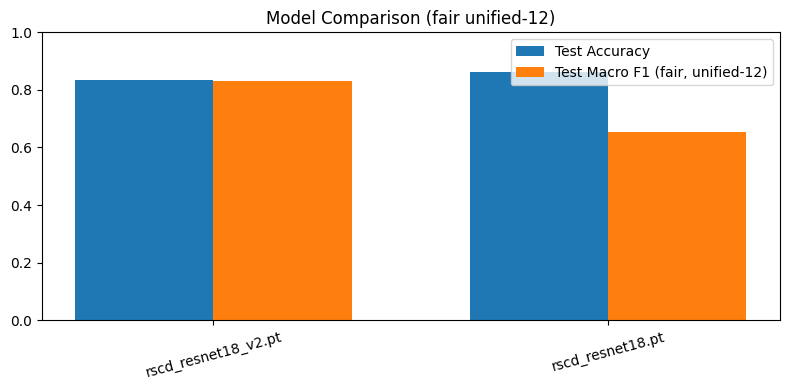

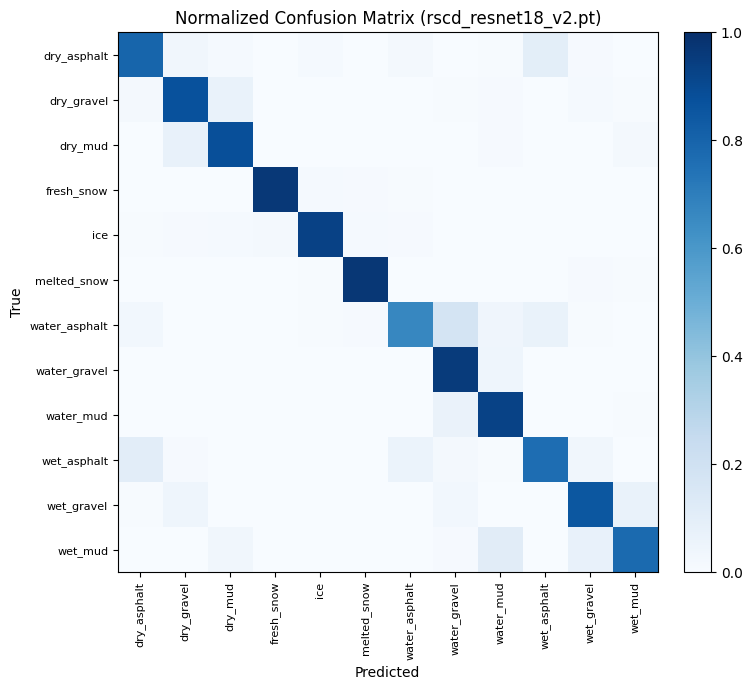

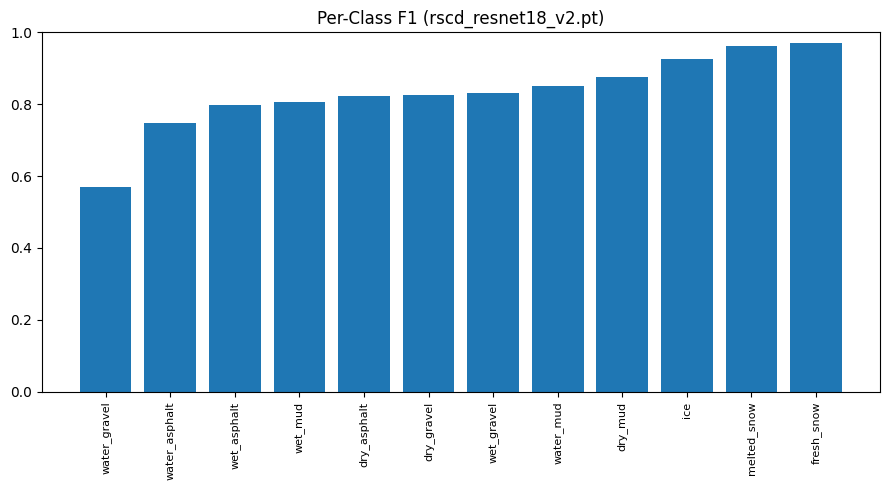

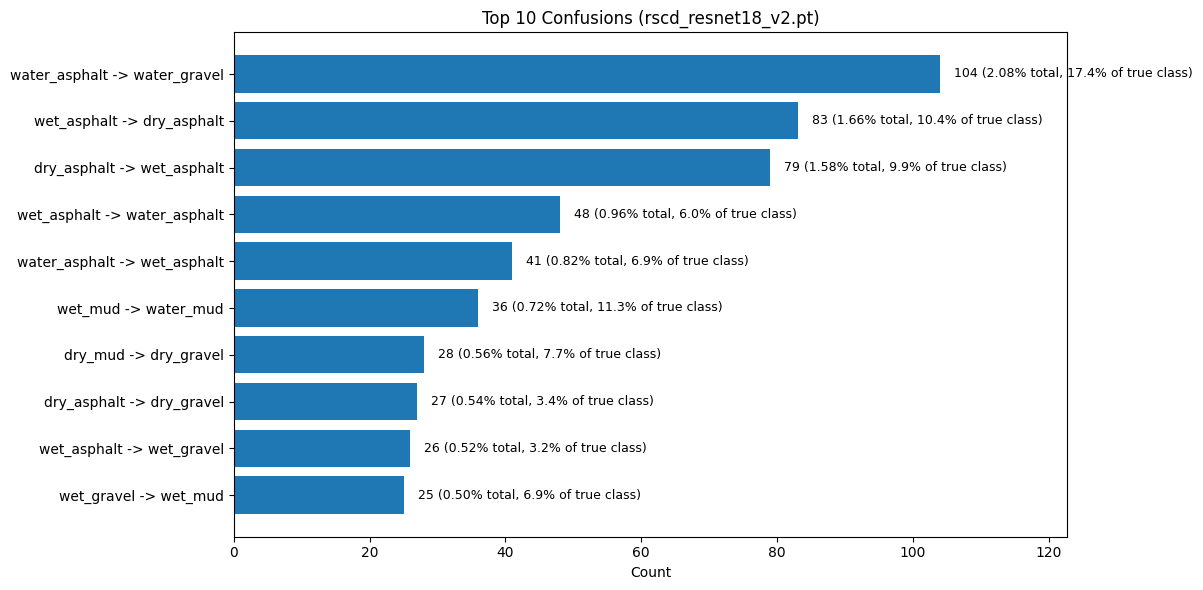

In [25]:
# Report figures from cached summary (fair unified-12 model comparison)
if not results:
    raise RuntimeError('No results loaded.')


def getv(r, split, key):
    if split in r and isinstance(r[split], dict):
        return r[split].get(key)
    return r.get(f'{split}_{key}')


def map_to_unified_12(label: str, allowed: set[str]) -> str | None:
    s = str(label)
    if 'concrete' in s:
        if s.startswith('dry_') or s.startswith('wet_') or s.startswith('water_'):
            s = s.replace('concrete', 'asphalt')
    for suf in ('_severe', '_slight', '_smooth'):
        if s.endswith(suf):
            s = s[: -len(suf)]
            break
    return s if s in allowed else None


def confusion_to_macro_f1(cm: np.ndarray) -> float:
    tp = np.diag(cm).astype(float)
    pred_pos = cm.sum(axis=0).astype(float)
    actual_pos = cm.sum(axis=1).astype(float)
    precision = np.divide(tp, pred_pos, out=np.zeros_like(tp), where=pred_pos > 0)
    recall = np.divide(tp, actual_pos, out=np.zeros_like(tp), where=actual_pos > 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp), where=(precision + recall) > 0)
    return float(f1.mean())


# Build fair metrics in a unified 12-class space for all checkpoints
row12 = next((r for r in results if int(r.get('n_classes', 0)) == 12), None)
if row12 is not None and row12.get('class_names'):
    unified_classes = list(row12['class_names'])
else:
    unified_classes = [
        'dry_asphalt', 'dry_gravel', 'dry_mud', 'fresh_snow', 'ice', 'melted_snow',
        'water_asphalt', 'water_gravel', 'water_mud', 'wet_asphalt', 'wet_gravel', 'wet_mud'
    ]

allowed = set(unified_classes)
idx = {c: i for i, c in enumerate(unified_classes)}
fair = []
for r in results:
    cm = np.array(r['test']['confusion'], dtype=int)
    src_classes = list(r.get('class_names', [str(i) for i in range(cm.shape[0])]))
    ucm = np.zeros((len(unified_classes), len(unified_classes)), dtype=int)
    for i, true_label in enumerate(src_classes):
        mt = map_to_unified_12(true_label, allowed)
        for j, pred_label in enumerate(src_classes):
            v = int(cm[i, j])
            if v == 0:
                continue
            mp = map_to_unified_12(pred_label, allowed)
            if mt is None or mp is None:
                continue
            ucm[idx[mt], idx[mp]] += v

    fair.append({
        'row': r,
        'name': Path(r['checkpoint']).name,
        'test_acc': float(getv(r, 'test', 'accuracy')),
        'test_macro_f1_fair': confusion_to_macro_f1(ucm),
    })

fair = sorted(fair, key=lambda x: x['test_macro_f1_fair'], reverse=True)

# 1) single model-comparison figure (Accuracy + FAIR Macro-F1)
names = [f['name'] for f in fair]
accs = [f['test_acc'] for f in fair]
f1s = [f['test_macro_f1_fair'] for f in fair]
x = np.arange(len(names))
w = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - w/2, accs, width=w, label='Test Accuracy')
plt.bar(x + w/2, f1s, width=w, label='Test Macro F1 (fair, unified-12)')
plt.xticks(x, names, rotation=15)
plt.ylim(0,1)
plt.title('Model Comparison (fair unified-12)')
plt.legend()
plt.tight_layout()
plt.show()

# pick best model by FAIR macro F1 for detailed error analysis plots
best_entry = max(fair, key=lambda x: x['test_macro_f1_fair'])
best = best_entry['row']
name = best_entry['name']

# 2) confusion matrix (best fair model)
if 'test' in best and isinstance(best['test'], dict) and 'confusion' in best['test']:
    cm = np.array(best['test']['confusion'], dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    cmn = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums > 0)
    labels = best.get('class_names', [str(i) for i in range(cm.shape[0])])
    plt.figure(figsize=(8,7))
    plt.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xticks(range(len(labels)), labels, rotation=90, fontsize=8)
    plt.yticks(range(len(labels)), labels, fontsize=8)
    plt.title(f'Normalized Confusion Matrix ({name})')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()
else:
    print('Confusion matrix not present in summary. Re-run evaluation script to include it.')

# 3) per-class F1 from confusion (best fair model)
if 'test' in best and isinstance(best['test'], dict) and 'confusion' in best['test']:
    cm = np.array(best['test']['confusion'], dtype=float)
    tp = np.diag(cm)
    pred_pos = cm.sum(axis=0)
    actual_pos = cm.sum(axis=1)
    precision = np.divide(tp, pred_pos, out=np.zeros_like(tp), where=pred_pos > 0)
    recall = np.divide(tp, actual_pos, out=np.zeros_like(tp), where=actual_pos > 0)
    f1 = np.divide(2*precision*recall, precision+recall, out=np.zeros_like(tp), where=(precision+recall)>0)
    labels = best.get('class_names', [str(i) for i in range(len(f1))])
    order = np.argsort(f1)
    plt.figure(figsize=(9,5))
    plt.bar(np.array(labels)[order], f1[order])
    plt.xticks(rotation=90, fontsize=8)
    plt.ylim(0,1)
    plt.title(f'Per-Class F1 ({name})')
    plt.tight_layout()
    plt.show()

# 4) top confusion pairs (best fair model)
if 'test' in best and isinstance(best['test'], dict) and 'confusion' in best['test']:
    cm = np.array(best['test']['confusion'], dtype=int)
    labels = best.get('class_names', [str(i) for i in range(cm.shape[0])])
    total_n = int(cm.sum())
    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)

    pairs = []
    flat_idx = np.argsort(cm_off, axis=None)[::-1]
    for idx_flat in flat_idx:
        count = int(cm_off.flat[idx_flat])
        if count <= 0:
            break
        i, j = np.unravel_index(idx_flat, cm_off.shape)
        true_support = int(cm[i, :].sum())
        pct_total = (100.0 * count / total_n) if total_n > 0 else 0.0
        pct_true = (100.0 * count / true_support) if true_support > 0 else 0.0
        pair_label = f"{labels[i]} -> {labels[j]}"
        annot = f"{count} ({pct_total:.2f}% total, {pct_true:.1f}% of true class)"
        pairs.append((pair_label, count, annot))
        if len(pairs) >= 10:
            break

    if pairs:
        names_h = [p[0] for p in pairs][::-1]
        counts = [p[1] for p in pairs][::-1]
        annots = [p[2] for p in pairs][::-1]
        plt.figure(figsize=(12, 6))
        bars = plt.barh(names_h, counts)
        plt.title(f'Top 10 Confusions ({name})')
        plt.xlabel('Count')

        max_count = max(counts)
        outside_pad = max(0.3, 0.02 * max_count)
        plt.xlim(0, max_count + 9 * outside_pad)

        for bar, txt in zip(bars, annots):
            x = bar.get_width()
            y = bar.get_y() + bar.get_height() / 2
            plt.text(x + outside_pad, y, txt, va='center', ha='left', fontsize=9)

        plt.tight_layout()
        plt.show()



### Notes
- Default workflow: run evaluation once with `evaluate_saved_models.py`, then keep `RUN_EVALUATION = False` in notebook.
- For fast reruns in notebook, only regenerate plots from `eval_summary.json`.
- If `confusion` is missing in summary, run the updated script once to refresh the JSON.
- macOS notebook multiprocessing issue: keep `NUM_WORKERS = 0` in notebook cells.
- Added a Top-10 confusion-pairs chart for clearer error analysis in the report.
- Top-confusion chart now annotates each pair with count, % of test set, and % of true class support.
